# **Tomato plant leaf disease classification and Detection**

Dataset Link : https://www.kaggle.com/datasets/ashishmotwani/tomato

## **Dataset Downloading**

**Google Colab**

In [1]:
!pip install -q kaggle

In [2]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"efficient8","key":"0e26061c5d5cf73b850e01f7c6575016"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d ashishmotwani/tomato

!unzip tomato.zip


Streaming output truncated to the last 5000 lines.
  inflating: valid/Late_blight/9aaf4a7d-12ac-457a-a18c-1f7ea13065de___RS_Late.B 5179.JPG  
  inflating: valid/Late_blight/9afc2537-1b13-4c25-b5ed-5b8de511b0ab___GHLB2 Leaf 9033.JPG  
  inflating: valid/Late_blight/9bb49d22-976d-40c3-bc9a-bff5cbbd8e28___RS_Late.B 5057.JPG  
  inflating: valid/Late_blight/9c274db5-2f89-4f3c-b9e2-4d5ebc54ddad___GHLB2 Leaf 9096.JPG  
  inflating: valid/Late_blight/9c726f4e-045b-4080-b53d-d7e66d45bcb1___RS_Late.B 4876.JPG  
  inflating: valid/Late_blight/9e5dd34f-124c-4a64-ba9f-77c8d05faa9c___GHLB2 Leaf 8749.JPG  
  inflating: valid/Late_blight/9e633823-3dde-450c-8172-733021e4dff0___RS_Late.B 6414.JPG  
  inflating: valid/Late_blight/9ecb8001-2f48-4487-b287-535dbcfb5c2f___RS_Late.B 6206.JPG  
  inflating: valid/Late_blight/9f7dcd60-e691-4c1e-830e-7495f7cc123d___RS_Late.B 6166.JPG  
  inflating: valid/Late_blight/Bacterial_spots2276_jpg.rf.5becd3793ec2a532bf8f111d60911c63.jpg  
  inflating: valid/Late_blight

**Libraries**

In [4]:
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import tensorflow as tf
import random
from PIL import Image
warnings.filterwarnings('ignore')

## **Raw Image Data Preprocessing**

In [7]:
train_dir = "train"
val_dir = "valid"

In [8]:
list_of_directories = os.listdir(train_dir)
classes_to_keep = []

for dir in list_of_directories:
    dir_path = os.path.join(train_dir, dir)
    count_of_images = len(os.listdir(dir_path))
    if count_of_images >= 2700:
        classes_to_keep.append(dir)

In [9]:
classes_to_keep

['Septoria_leaf_spot', 'Late_blight', 'healthy', 'Leaf_Mold', 'Bacterial_spot']

In [10]:
def remove_dirs(dir, classes_to_keep):
    for d in os.listdir(dir):
        if d not in classes_to_keep:
            shutil.rmtree(os.path.join(dir,d))

In [11]:
remove_dirs(train_dir, classes_to_keep)

In [12]:
remove_dirs(val_dir, classes_to_keep)

**Renaming Folder Names**

In [13]:
train_dir = "train"
val_dir = "valid"

train_images_dir = list(os.listdir(train_dir))
val_images_dir = list(os.listdir(val_dir))

print(f"Images directory names in train data\n {train_images_dir}\n")
print(f"Images directory names in validation data\n {val_images_dir}")

Images directory names in train data
 ['Septoria_leaf_spot', 'Late_blight', 'healthy', 'Leaf_Mold', 'Bacterial_spot']

Images directory names in validation data
 ['Septoria_leaf_spot', 'Late_blight', 'healthy', 'Leaf_Mold', 'Bacterial_spot']


In [14]:
# Train Image Dir renaming
def renaming(list_of_dirs, dir_path):
    for r in range(len(list_of_dirs)):
        old_path = os.path.join(dir_path, list_of_dirs[r])
        new_path = os.path.join(dir_path, list_of_dirs[r].replace("_", " "))
        os.rename(old_path, new_path)
    print(f"{dir_path} successfully renamed")

renaming(train_images_dir, "train")

train successfully renamed


In [15]:
renaming(val_images_dir, "valid")
print("All files renamed successfully in train data")

valid successfully renamed
All files renamed successfully in train data


**Train Data Count**

In [16]:
train_dir = "train"

list_of_directories = os.listdir(train_dir)
counts = []

for dir in list_of_directories:
    dir_path = os.path.join(train_dir, dir)
    count_of_images = len(os.listdir(dir_path))
    counts.append(count_of_images)
    print(f"{dir} has {count_of_images} images")

Septoria leaf spot has 2882 images
Late blight has 3113 images
Leaf Mold has 2754 images
Bacterial spot has 2826 images
healthy has 3051 images


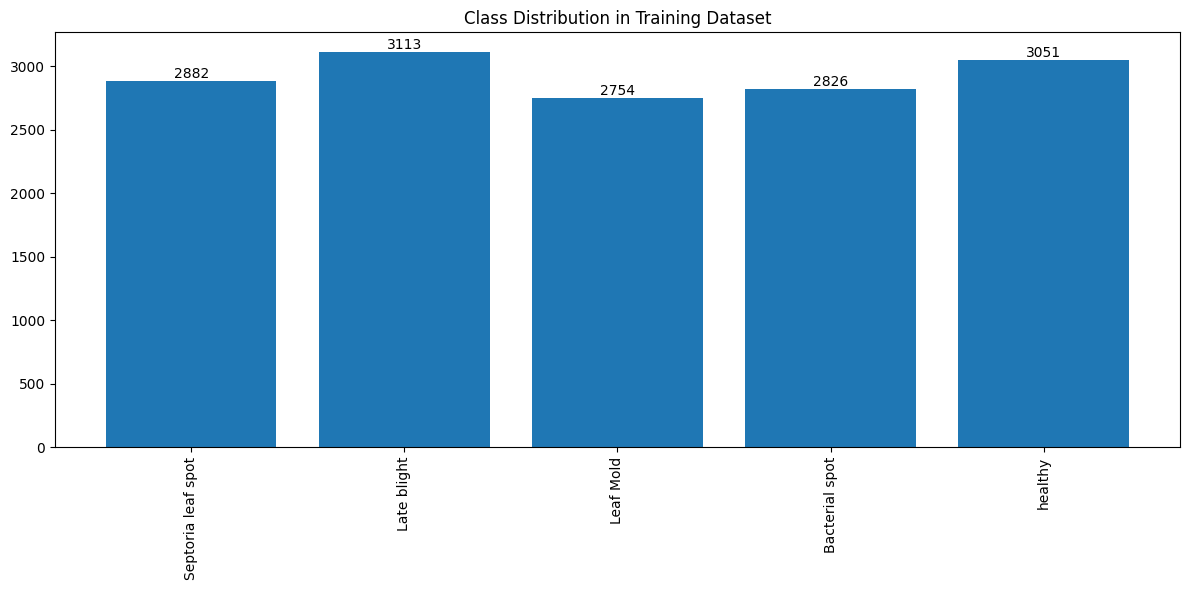

In [17]:
plt.figure(figsize=(12,6))

bars = plt.bar(list_of_directories, counts)

plt.xticks(rotation=90)
plt.title("Class Distribution in Training Dataset")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             str(height), ha='center', va='bottom')

plt.tight_layout()
plt.show()

**Validation Data Count**

In [18]:
val_dir = "valid"

list_of_directories_valid = os.listdir(val_dir)
valid_count_images = []

for dir in list_of_directories_valid:
    dir_path = os.path.join(val_dir, dir)
    count_of_images = len(os.listdir(dir_path))
    valid_count_images.append(count_of_images)
    print(f"{dir} has {count_of_images} images")

Septoria leaf spot has 746 images
Late blight has 792 images
Leaf Mold has 739 images
Bacterial spot has 732 images
healthy has 805 images


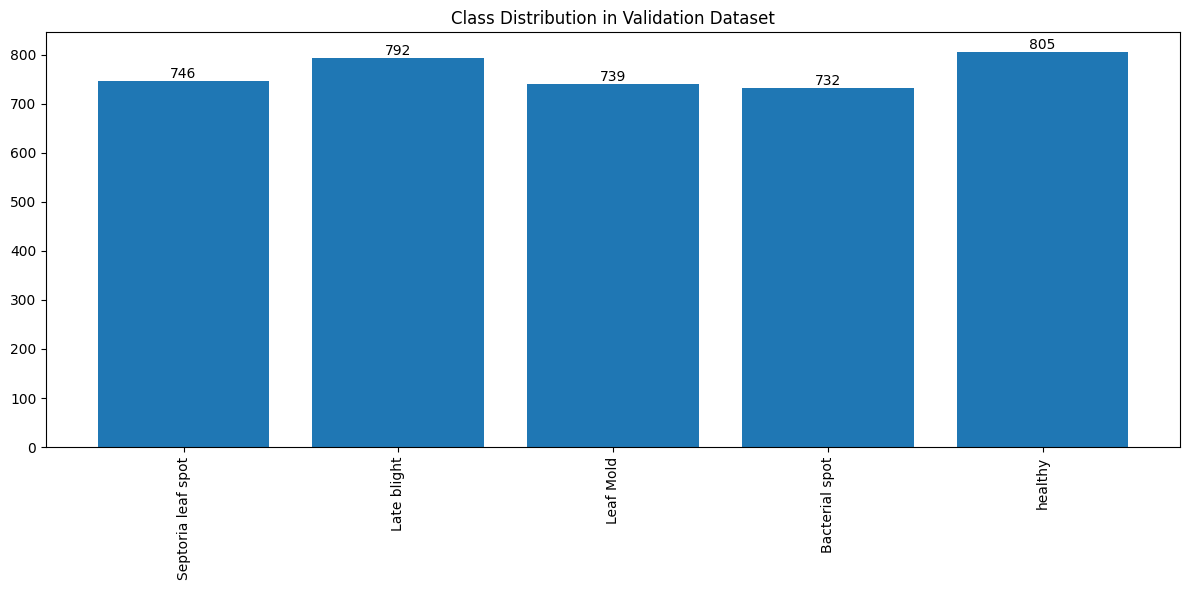

In [19]:
plt.figure(figsize=(12,6))

bars = plt.bar(list_of_directories_valid, valid_count_images)

plt.xticks(rotation=90)
plt.title("Class Distribution in Validation Dataset")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             str(height), ha='center', va='bottom')

plt.tight_layout()
plt.show()

**Test Data Creation**

In [20]:
train_dir = "train"
test_dir = "test"

# Create validation directory if not exists
os.makedirs(test_dir, exist_ok=True)

for class_name in os.listdir(train_dir):

    class_train_path = os.path.join(train_dir, class_name)
    class_test_path = os.path.join(test_dir, class_name)

    # Skip if not directory
    if not os.path.isdir(class_train_path):
        continue

    os.makedirs(class_test_path, exist_ok=True)

    images = os.listdir(class_train_path)
    random.shuffle(images)

    # 15% split
    split_size = int(0.15 * len(images))
    val_images = images[:split_size]

    for img in val_images:
        src_path = os.path.join(class_train_path, img)
        dst_path = os.path.join(class_test_path, img)
        shutil.move(src_path, dst_path)

print("Test data created")

Test data created


**Overall Count**

In [21]:
train_dir = "train"
test_dir = "test"
val_dir = "valid"

train_list_of_directories = os.listdir(train_dir)

In [22]:
print("Train Data after Validation Data creation")
print("="*50)
for dir in train_list_of_directories:
    dir_path = os.path.join(train_dir, dir)
    count_of_images = len(os.listdir(dir_path))
    print(f"{dir} has {count_of_images} images")

Train Data after Validation Data creation
Septoria leaf spot has 2450 images
Late blight has 2647 images
Leaf Mold has 2341 images
Bacterial spot has 2403 images
healthy has 2594 images


In [23]:
print("\nTest Data Count")
print("="*50)
test_list_of_directories = os.listdir(test_dir)

for dir in test_list_of_directories:
    dir_path = os.path.join(test_dir, dir)
    count_of_images = len(os.listdir(dir_path))
    print(f"{dir} has {count_of_images} images")


Test Data Count
Septoria leaf spot has 432 images
Late blight has 466 images
Leaf Mold has 413 images
Bacterial spot has 423 images
healthy has 457 images


In [24]:
print("\nValidation Data Count")
print("="*50)
val_list_of_directories = os.listdir(val_dir)

for dir in val_list_of_directories:
    dir_path = os.path.join(val_dir, dir)
    count_of_images = len(os.listdir(dir_path))
    print(f"{dir} has {count_of_images} images")


Validation Data Count
Septoria leaf spot has 746 images
Late blight has 792 images
Leaf Mold has 739 images
Bacterial spot has 732 images
healthy has 805 images


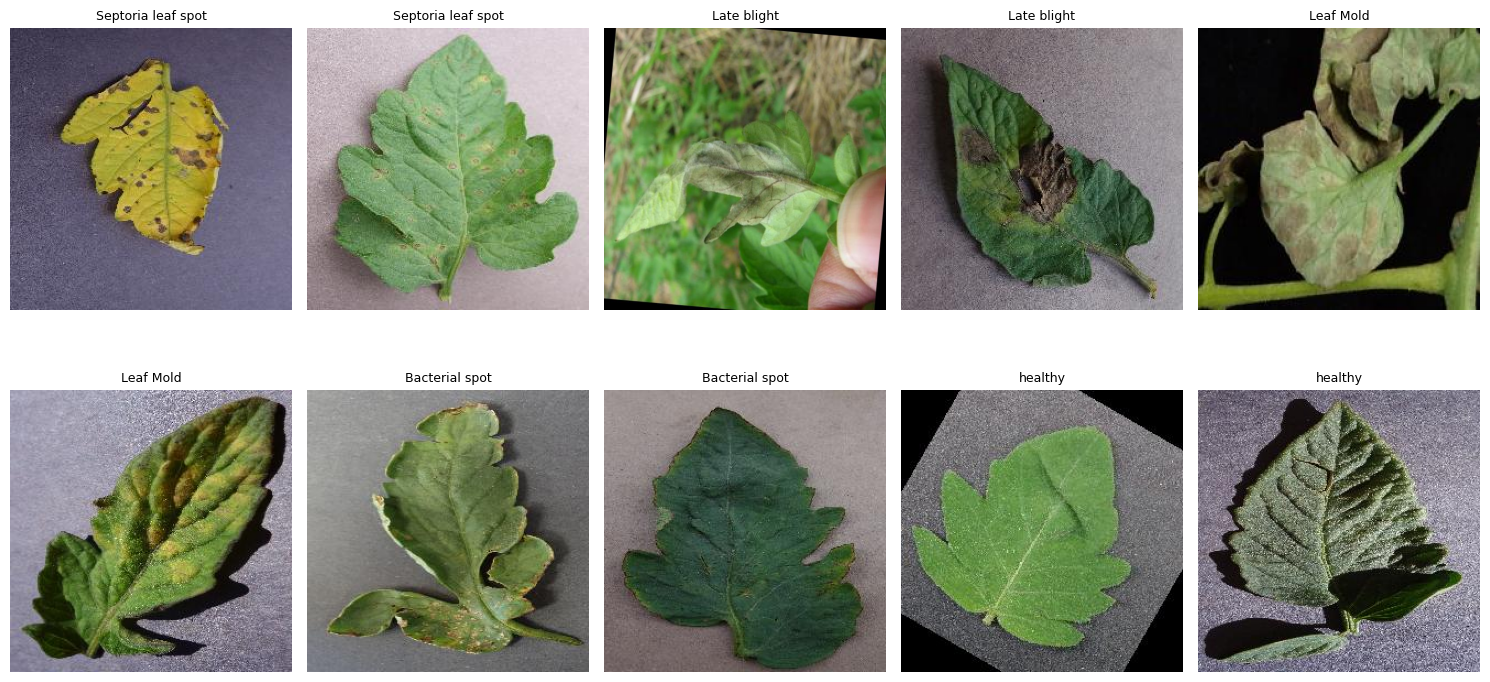

In [26]:
import random
import math

train_dir = "train"
classes = os.listdir(train_dir)

images_per_class = 2
total_images = len(classes) * images_per_class

cols = 5
rows = 2

plt.figure(figsize=(15, 4 * rows))

plot_index = 1

for class_name in classes:
    class_path = os.path.join(train_dir, class_name)

    images = random.sample(os.listdir(class_path), images_per_class)

    for img_name in images:
        img_path = os.path.join(class_path, img_name)
        img = Image.open(img_path)

        plt.subplot(rows, cols, plot_index)
        plt.imshow(img)
        plt.title(class_name, fontsize=9)
        plt.axis("off")

        plot_index += 1

plt.tight_layout()
plt.show()

## **Data Augmentation**

In [39]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [40]:
train_dir = "train"
val_dir = "valid"
test_dir = "test"

In [41]:
batch_size=64
img_size = (224, 224)

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

Found 12435 images belonging to 5 classes.


In [42]:
val_datagen = ImageDataGenerator(rescale=1./255)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

test_generator = val_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 3814 images belonging to 5 classes.
Found 2191 images belonging to 5 classes.


## **Model Building**

In [43]:
all_model_metrics = []
class_len = 5

#### **CNN Model**

In [44]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Dropout, Input
from tensorflow.keras.optimizers import Adam

In [45]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

callbacks = [early_stop]

In [46]:
cnn_model = Sequential([
    Input(shape=(224,224,3)),

    # First block
    Conv2D(32, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(32, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    # Second block
    Conv2D(64, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    # Third block
    Conv2D(128, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    # Fourth block
    Conv2D(256, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(256, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.5),

    # Classifier
    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(class_len, activation='softmax')
])

In [47]:
from tensorflow.keras.metrics import F1Score

# Compile with different optimizer settings
cnn_model.compile(
    optimizer=Adam(learning_rate=0.0001, decay=1e-6),
    loss='categorical_crossentropy',
    metrics=['accuracy', 'precision', 'recall', F1Score(average='macro')]
)

In [48]:
# Train Model
cnn_history = cnn_model.fit(train_generator, epochs=10, verbose=1,
          validation_data=val_generator, callbacks=callbacks)

Epoch 1/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 287s 1s/step - accuracy: 0.5750 - f1_score: 0.5718 - loss: 1.2222 - precision: 0.6364 - recall: 0.5089 - val_accuracy: 0.1919 - val_f1_score: 0.0644 - val_loss: 2.8703 - val_precision: 0.1920 - val_recall: 0.1919
Epoch 2/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 210s 1s/step - accuracy: 0.7142 - f1_score: 0.7120 - loss: 0.7892 - precision: 0.7770 - recall: 0.6671 - val_accuracy: 0.2664 - val_f1_score: 0.1824 - val_loss: 3.2136 - val_precision: 0.2626 - val_recall: 0.2478
Epoch 3/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 200s 1s/step - accuracy: 0.7575 - f1_score: 0.7561 - loss: 0.6617 - precision: 0.8174 - recall: 0.7115 - val_accuracy: 0.5304 - val_f1_score: 0.5056 - val_loss: 1.6605 - val_precision: 0.5674 - val_recall: 0.5018
Epoch 4/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 201s 1s/step - accuracy: 0.7758 - f1_score: 0.7751 - loss: 0.6069 - precision: 0.8344 - recall: 0.7279 - val_accuracy: 0.6956 - val_f1_score: 0.6878 - val_loss: 0.9905 - val_precision: 0.7323 - val_rec

#### **VGG16**

In [49]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

callbacks = [early_stop]

In [51]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze initial layers, unfreeze later layers
for layer in base_model.layers[:15]:
    layer.trainable = False
for layer in base_model.layers[15:]:
    layer.trainable = True

# Build enhanced model
x = base_model.output
x = Flatten()(x)
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
predictions = Dense(class_len, activation='softmax')(x)

vgg_model = Model(inputs=base_model.input, outputs=predictions)

In [52]:
vgg_model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy', 'precision', 'recall', F1Score(average='macro')]
)

In [53]:
vgg_history = vgg_model.fit(train_generator, epochs=10, verbose=1,
          validation_data=val_generator, callbacks=callbacks)

Epoch 1/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 277s 1s/step - accuracy: 0.4437 - f1_score: 0.4395 - loss: 1.6261 - precision: 0.4925 - recall: 0.3680 - val_accuracy: 0.6133 - val_f1_score: 0.6075 - val_loss: 0.9789 - val_precision: 0.7387 - val_recall: 0.4641
Epoch 2/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 209s 1s/step - accuracy: 0.6333 - f1_score: 0.6284 - loss: 1.0645 - precision: 0.6805 - recall: 0.5805 - val_accuracy: 0.7729 - val_f1_score: 0.7670 - val_loss: 0.6390 - val_precision: 0.8306 - val_recall: 0.7213
Epoch 3/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 209s 1s/step - accuracy: 0.6973 - f1_score: 0.6926 - loss: 0.8766 - precision: 0.7392 - recall: 0.6585 - val_accuracy: 0.8167 - val_f1_score: 0.8131 - val_loss: 0.5441 - val_precision: 0.8507 - val_recall: 0.7784
Epoch 4/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 209s 1s/step - accuracy: 0.7363 - f1_score: 0.7330 - loss: 0.7545 - precision: 0.7779 - recall: 0.7034 - val_accuracy: 0.8270 - val_f1_score: 0.8237 - val_loss: 0.5117 - val_precision: 0.8602 - val_rec

#### **ResNet50**

In [54]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, BatchNormalization, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import F1Score

In [55]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

callbacks = [early_stop]

In [56]:
# Load ResNet50 base model
base_model_resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

for layer in base_model_resnet.layers[:140]:
    layer.trainable = False
for layer in base_model_resnet.layers[140:]:
    layer.trainable = True

# Build custom classification layers on top of ResNet50
x = base_model_resnet.output
x = Flatten()(x)
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
predictions = Dense(class_len, activation='softmax')(x)

resnet_model = Model(inputs=base_model_resnet.input, outputs=predictions)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [57]:
# Compile the model
resnet_model.compile(
    optimizer=Adam(learning_rate=0.00001), # Lower learning rate for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy', 'precision', 'recall', F1Score(average='macro')]
)

In [58]:
resnet_history = resnet_model.fit(train_generator, epochs=10, verbose=1,
          validation_data=val_generator, callbacks=callbacks)

Epoch 1/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 251s 1s/step - accuracy: 0.4194 - f1_score: 0.4108 - loss: 1.6825 - precision: 0.4749 - recall: 0.3157 - val_accuracy: 0.2111 - val_f1_score: 0.0698 - val_loss: 2.3019 - val_precision: 0.2172 - val_recall: 0.2105
Epoch 2/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 197s 1s/step - accuracy: 0.5099 - f1_score: 0.5010 - loss: 1.3913 - precision: 0.5716 - recall: 0.4158 - val_accuracy: 0.4698 - val_f1_score: 0.4347 - val_loss: 1.4536 - val_precision: 0.5345 - val_recall: 0.3574
Epoch 3/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 196s 1s/step - accuracy: 0.5501 - f1_score: 0.5418 - loss: 1.2504 - precision: 0.6170 - recall: 0.4610 - val_accuracy: 0.5420 - val_f1_score: 0.5109 - val_loss: 1.2154 - val_precision: 0.6274 - val_recall: 0.4583
Epoch 4/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 195s 994ms/step - accuracy: 0.5768 - f1_score: 0.5702 - loss: 1.1629 - precision: 0.6489 - recall: 0.4958 - val_accuracy: 0.6416 - val_f1_score: 0.6308 - val_loss: 0.9700 - val_precision: 0.6982 - val_

## **Metrics**

In [59]:
cnn_loss, cnn_accuracy, cnn_precision, cnn_recall, cnn_f1 = cnn_model.evaluate(test_generator)

35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 271ms/step - accuracy: 0.7754 - f1_score: 0.7781 - loss: 0.6976 - precision: 0.8144 - recall: 0.7508


In [60]:
print(f"Test Loss of CNN: {cnn_loss:.4f}")
print(f"Test Accuracy of CNN: {cnn_accuracy * 100:.2f}%")
print(f"Test Precision of CNN: {cnn_precision:.4f}")
print(f"Test Recall of CNN: {cnn_recall:.4f}")
print(f"Test F1 Score of CNN: {cnn_f1:.4f}")

Test Loss of CNN: 0.6976
Test Accuracy of CNN: 77.54%
Test Precision of CNN: 0.8144
Test Recall of CNN: 0.7508
Test F1 Score of CNN: 0.7781


In [61]:
cnn_metrics = {
    "Model Name": "CNN Model",
    "Accuracy": cnn_accuracy,
    "Precision": cnn_precision,
    "Recall": cnn_recall,
    "F1": cnn_f1
}

all_model_metrics.append(cnn_metrics)

In [62]:
vgg_loss, vgg_accuracy, vgg_precision, vgg_recall, vgg_f1 = vgg_model.evaluate(test_generator)

35/35 ━━━━━━━━━━━━━━━━━━━━ 23s 659ms/step - accuracy: 0.8850 - f1_score: 0.8836 - loss: 0.3173 - precision: 0.9098 - recall: 0.8654


In [63]:
print(f"Test Loss of VGG16: {vgg_loss:.4f}")
print(f"Test Accuracy of VGG16: {vgg_accuracy * 100:.2f}%")
print(f"Test Precision of VGG16: {vgg_precision:.4f}")
print(f"Test Recall of VGG16: {vgg_recall:.4f}")
print(f"Test F1 Score of VGG16: {vgg_f1:.4f}")

Test Loss of VGG16: 0.3173
Test Accuracy of VGG16: 88.50%
Test Precision of VGG16: 0.9098
Test Recall of VGG16: 0.8654
Test F1 Score of VGG16: 0.8836


In [64]:
vgg_metrics = {
    "Model Name": "VGG16 Model",
    "Accuracy": vgg_accuracy,
    "Precision": vgg_precision,
    "Recall": vgg_recall,
    "F1": vgg_f1
}

all_model_metrics.append(vgg_metrics)

In [65]:
resnet_loss, resnet_accuracy, resnet_precision, resnet_recall, resnet_f1 = resnet_model.evaluate(test_generator)

35/35 ━━━━━━━━━━━━━━━━━━━━ 12s 333ms/step - accuracy: 0.7052 - f1_score: 0.6972 - loss: 0.8238 - precision: 0.7851 - recall: 0.6385


In [66]:
print(f"Test Loss of resnet: {resnet_loss:.4f}")
print(f"Test Accuracy of resNet: {resnet_accuracy * 100:.2f}%")
print(f"Test Precision of resNet: {resnet_precision:.4f}")
print(f"Test Recall of resNet: {resnet_recall:.4f}")
print(f"Test F1 Score of resNet: {resnet_f1:.4f}")

Test Loss of resnet: 0.8238
Test Accuracy of resNet: 70.52%
Test Precision of resNet: 0.7851
Test Recall of resNet: 0.6385
Test F1 Score of resNet: 0.6972


In [68]:
resnet_metrics = {
    "Model Name": "ResNet Model",
    "Accuracy":resnet_accuracy,
    "Precision":resnet_precision,
    "Recall":resnet_recall,
    "F1":resnet_f1
}

all_model_metrics.append(resnet_metrics)

In [69]:
final_metrics = pd.DataFrame(all_model_metrics)
final_metrics = final_metrics.sort_values(by="Accuracy", ascending=True)
final_metrics

,Model Name,Accuracy,Precision,Recall,F1
2,ResNet Model,0.705157,0.785073,0.638521,0.697208
0,CNN Model,0.775445,0.814356,0.750799,0.778124
1,VGG16 Model,0.884984,0.909789,0.865358,0.883621


## **Accuracy & Loss Plots**

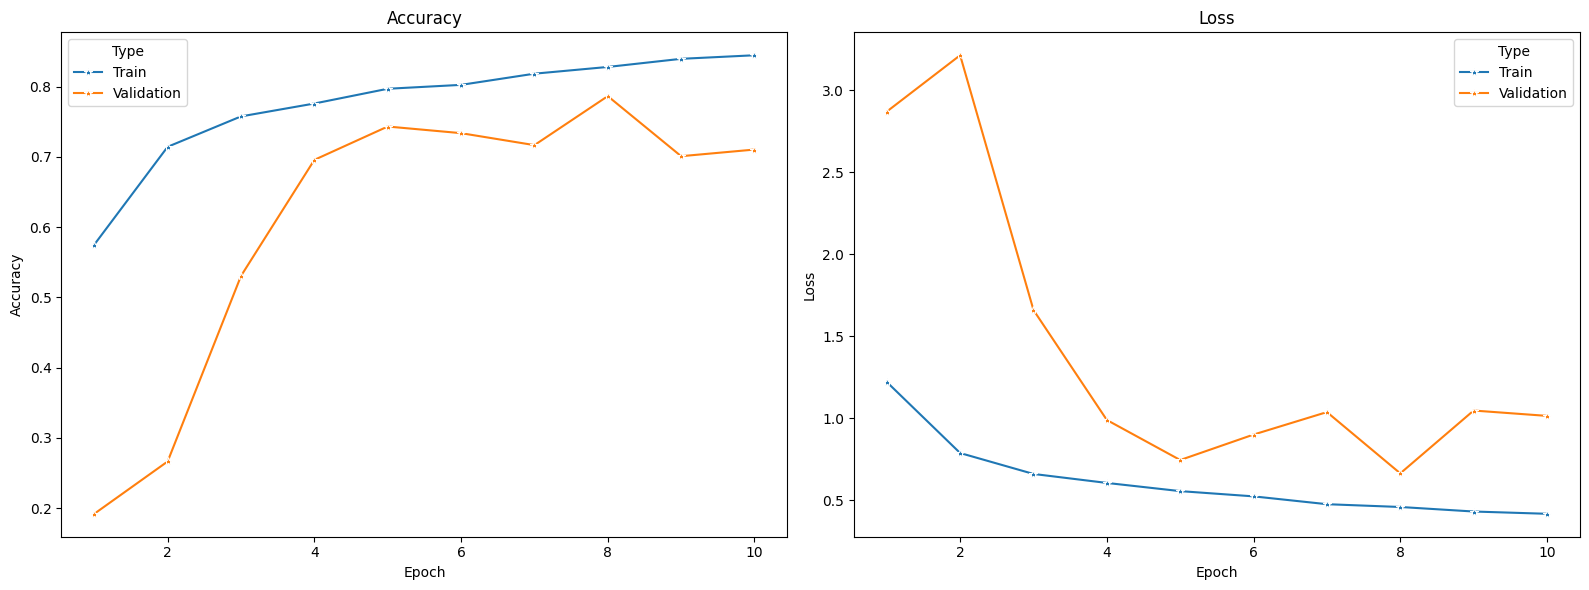

In [72]:
# Extract values
acc = cnn_history.history['accuracy']
val_acc = cnn_history.history['val_accuracy']
loss = cnn_history.history['loss']
val_loss = cnn_history.history['val_loss']
epochs = range(1, len(acc) + 1)

# DataFrames
df_acc = pd.DataFrame({
    'Epoch': list(epochs) * 2,
    'Value': acc + val_acc,
    'Type': ['Train'] * len(acc) + ['Validation'] * len(val_acc)
})

df_loss = pd.DataFrame({
    'Epoch': list(epochs) * 2,
    'Value': loss + val_loss,
    'Type': ['Train'] * len(loss) + ['Validation'] * len(val_loss)
})

# Create subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy plot
sns.lineplot(data=df_acc, x='Epoch', y='Value', hue='Type', marker='*', ax=axes[0])
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')

# Loss plot
sns.lineplot(data=df_loss, x='Epoch', y='Value', hue='Type', marker='*', ax=axes[1])
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')

plt.tight_layout()
plt.show()

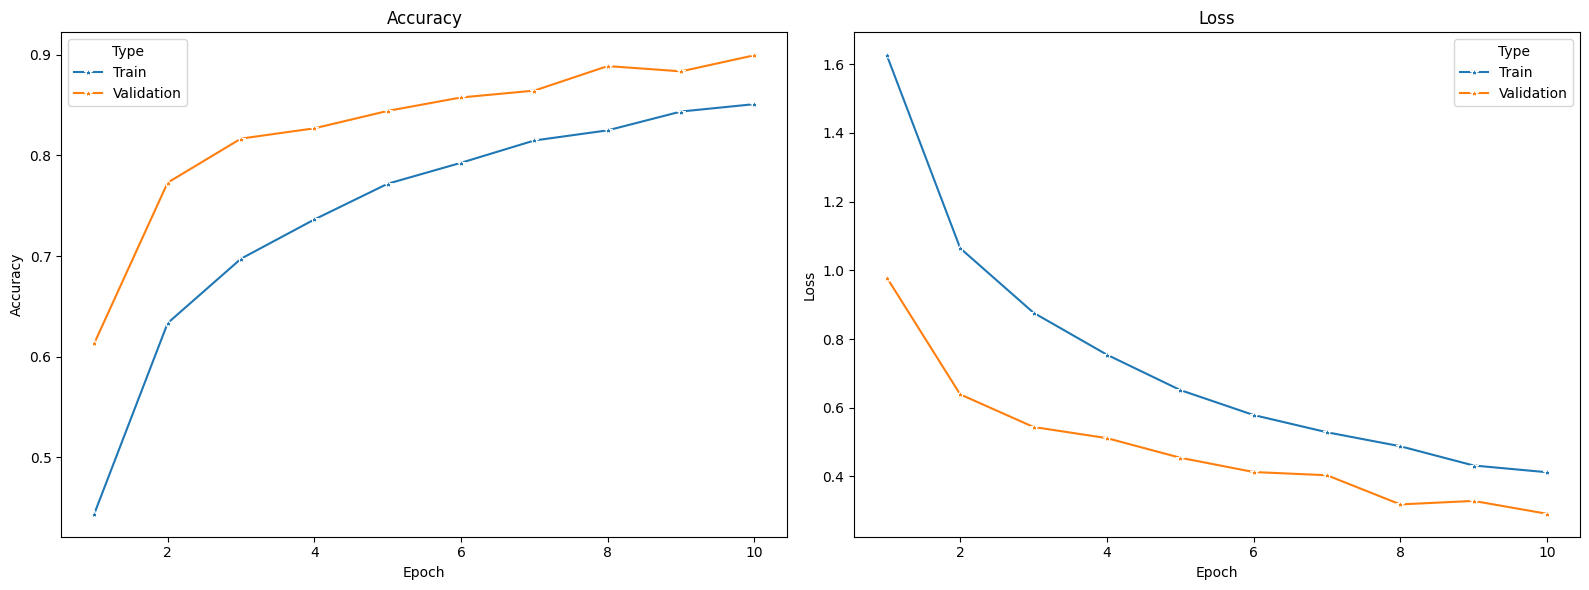

In [73]:
# Extract values
acc = vgg_history.history['accuracy']
val_acc = vgg_history.history['val_accuracy']
loss = vgg_history.history['loss']
val_loss = vgg_history.history['val_loss']
epochs = range(1, len(acc) + 1)

# DataFrames
df_acc = pd.DataFrame({
    'Epoch': list(epochs) * 2,
    'Value': acc + val_acc,
    'Type': ['Train'] * len(acc) + ['Validation'] * len(val_acc)
})

df_loss = pd.DataFrame({
    'Epoch': list(epochs) * 2,
    'Value': loss + val_loss,
    'Type': ['Train'] * len(loss) + ['Validation'] * len(val_loss)
})

# Create subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy plot
sns.lineplot(data=df_acc, x='Epoch', y='Value', hue='Type', marker='*', ax=axes[0])
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')

# Loss plot
sns.lineplot(data=df_loss, x='Epoch', y='Value', hue='Type', marker='*', ax=axes[1])
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')

plt.tight_layout()
plt.show()

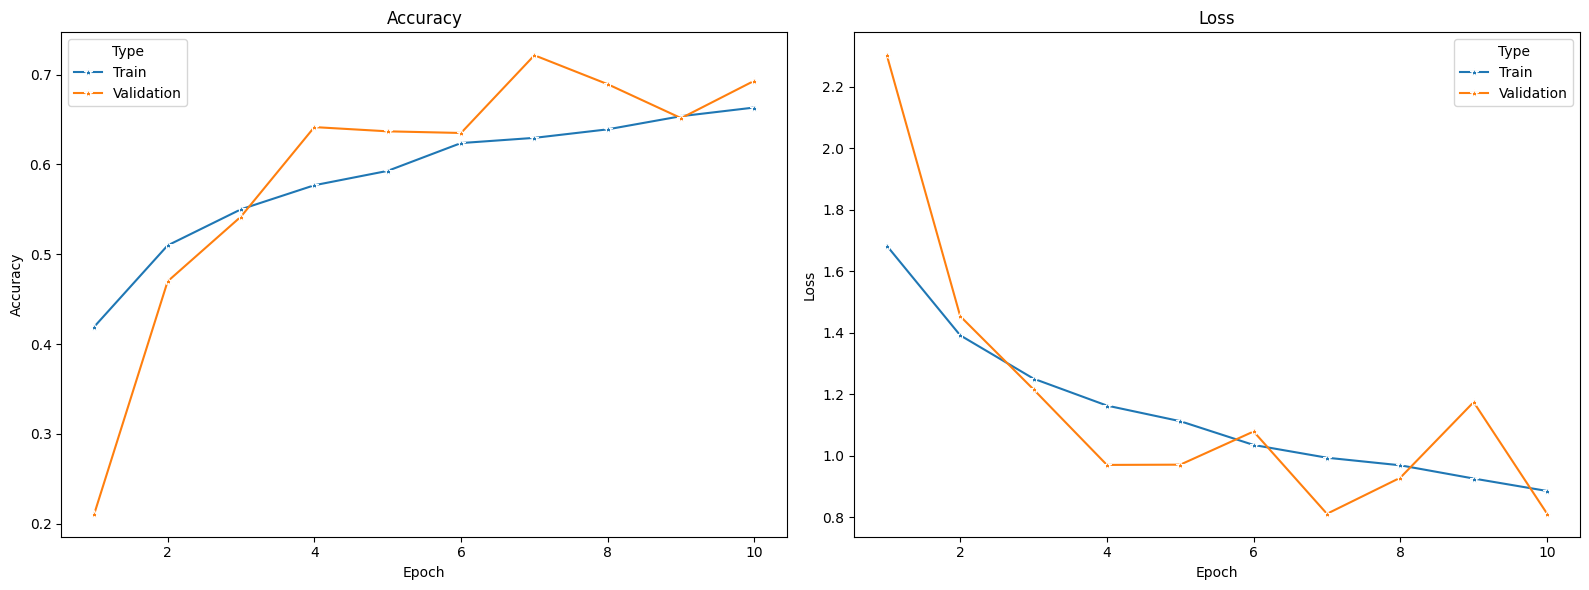

In [75]:
# Extract values
acc = resnet_history.history['accuracy']
val_acc = resnet_history.history['val_accuracy']
loss = resnet_history.history['loss']
val_loss = resnet_history.history['val_loss']
epochs = range(1, len(acc) + 1)

# DataFrames
df_acc = pd.DataFrame({
    'Epoch': list(epochs) * 2,
    'Value': acc + val_acc,
    'Type': ['Train'] * len(acc) + ['Validation'] * len(val_acc)
})

df_loss = pd.DataFrame({
    'Epoch': list(epochs) * 2,
    'Value': loss + val_loss,
    'Type': ['Train'] * len(loss) + ['Validation'] * len(val_loss)
})

# Create subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy plot
sns.lineplot(data=df_acc, x='Epoch', y='Value', hue='Type', marker='*', ax=axes[0])
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')

# Loss plot
sns.lineplot(data=df_loss, x='Epoch', y='Value', hue='Type', marker='*', ax=axes[1])
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')

plt.tight_layout()
plt.show()

## **Confusion Matrix**

35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 234ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 13s 357ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 15s 332ms/step


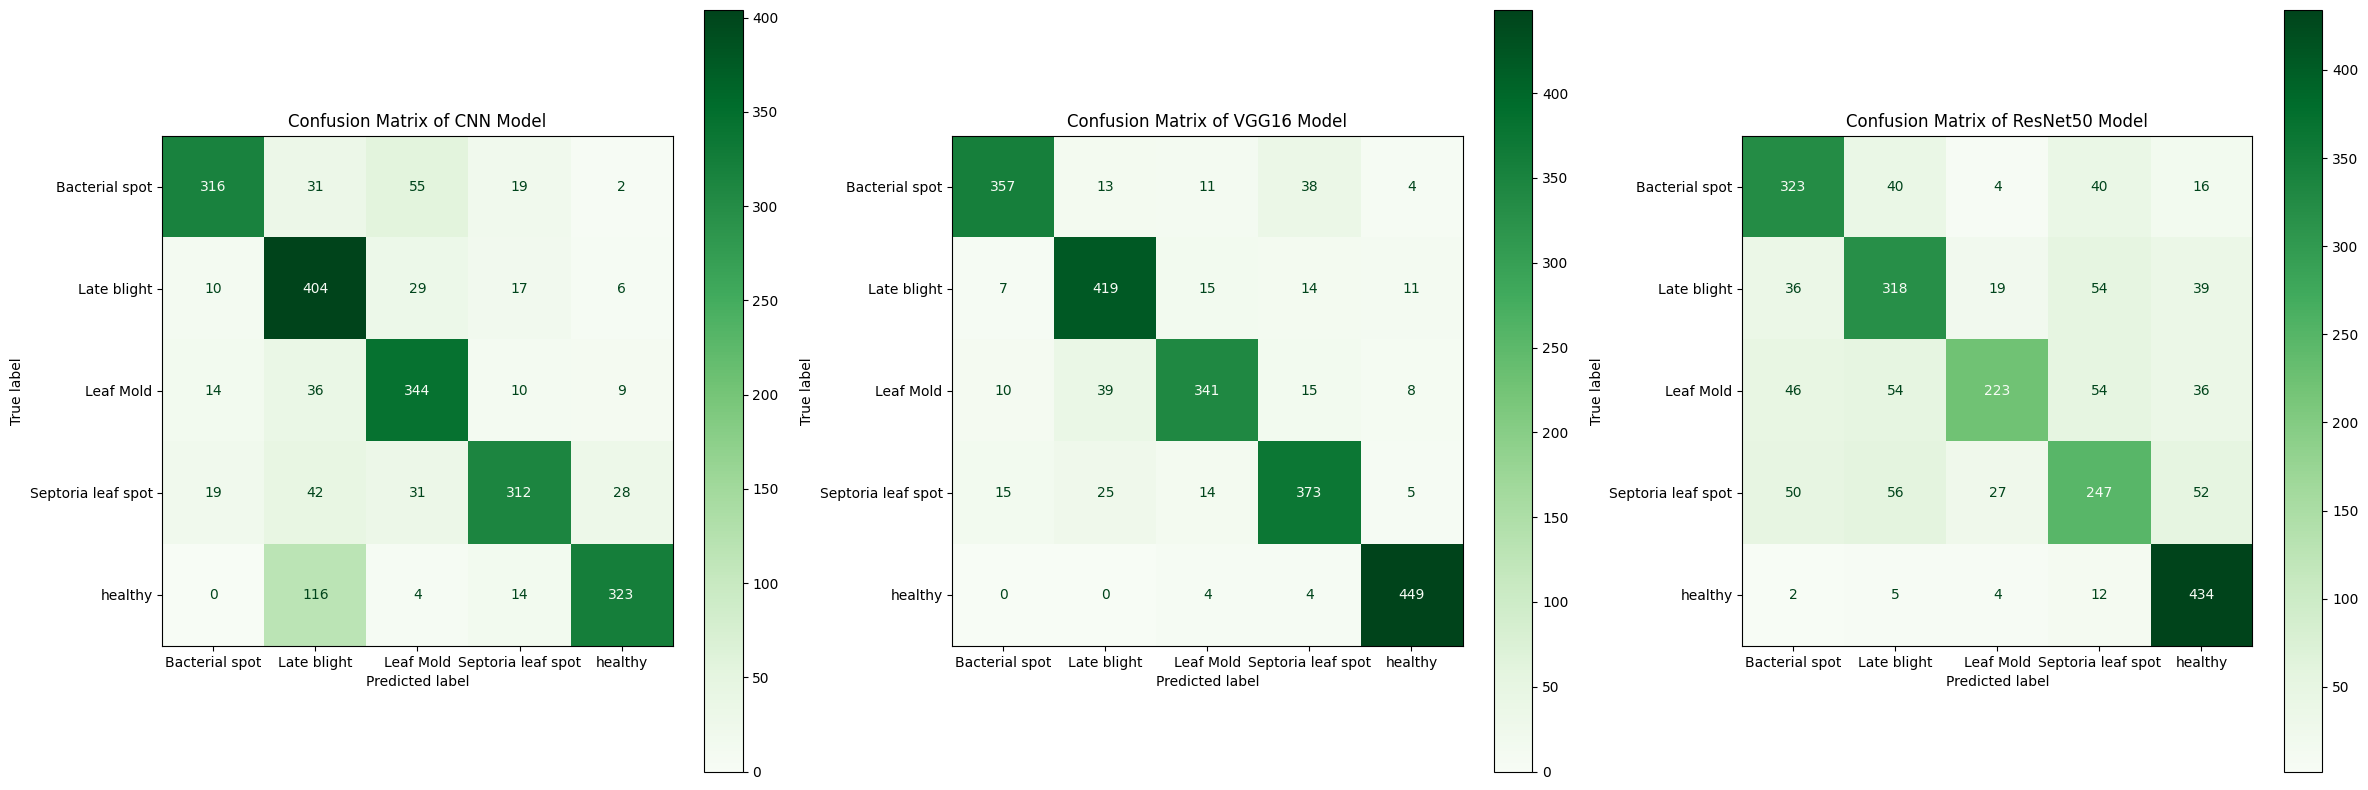

In [76]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

test_generator.reset()

y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

fig, axes = plt.subplots(1, 3, figsize=(24, 8)) # 1 row, 3 columns

# --- CNN Model Confusion Matrix ---
y_pred_probs_cnn = cnn_model.predict(test_generator)
y_pred_cnn = np.argmax(y_pred_probs_cnn, axis=1)
cm_cnn = confusion_matrix(y_true, y_pred_cnn)
disp_cnn = ConfusionMatrixDisplay(confusion_matrix=cm_cnn, display_labels=class_labels)
disp_cnn.plot(cmap=plt.cm.Greens, values_format='d', ax=axes[0])
axes[0].set_title('Confusion Matrix of CNN Model')

# --- VGG16 Model Confusion Matrix ---
test_generator.reset()
y_pred_probs_vgg = vgg_model.predict(test_generator)
y_pred_vgg = np.argmax(y_pred_probs_vgg, axis=1)
cm_vgg = confusion_matrix(y_true, y_pred_vgg)
disp_vgg = ConfusionMatrixDisplay(confusion_matrix=cm_vgg, display_labels=class_labels)
disp_vgg.plot(cmap=plt.cm.Greens, values_format='d', ax=axes[1])
axes[1].set_title('Confusion Matrix of VGG16 Model')

# --- ResNet50 Model Confusion Matrix ---
test_generator.reset()
y_pred_probs_resnet = resnet_model.predict(test_generator)
y_pred_resnet = np.argmax(y_pred_probs_resnet, axis=1)
cm_resnet = confusion_matrix(y_true, y_pred_resnet)
disp_resnet = ConfusionMatrixDisplay(confusion_matrix=cm_resnet, display_labels=class_labels)
disp_resnet.plot(cmap=plt.cm.Greens, values_format='d', ax=axes[2])
axes[2].set_title('Confusion Matrix of ResNet50 Model')

plt.tight_layout()
plt.show()

## **Comparison Plots**

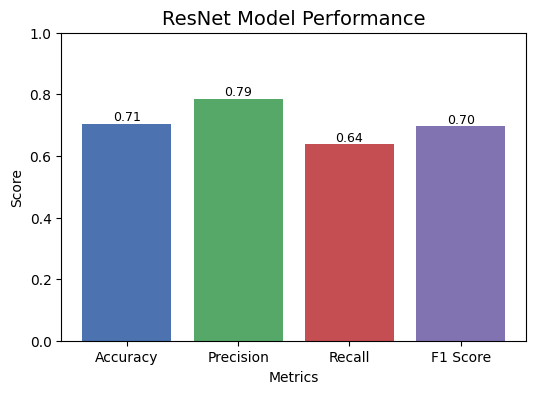

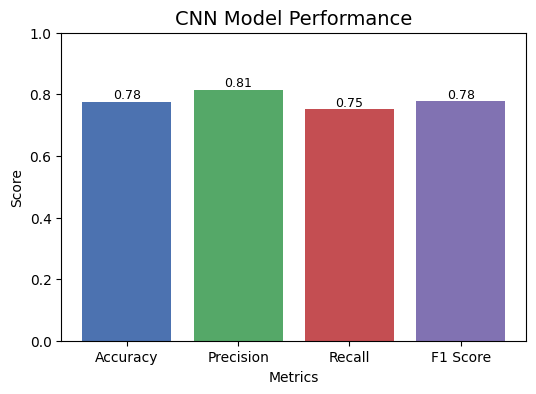

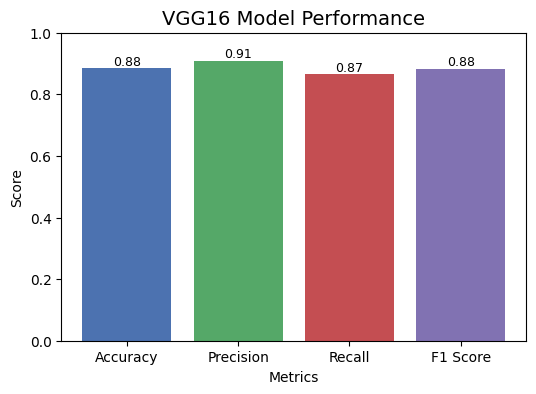

In [77]:
for idx, row in final_metrics.iterrows():
    metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
    values = [row["Accuracy"], row["Precision"], row["Recall"], row["F1"]]

    plt.figure(figsize=(6,4))
    plt.bar(metrics, values, color=["#4C72B0", "#55A868", "#C44E52", "#8172B2"])

    # Add value labels on top
    for i, v in enumerate(values):
        plt.text(i, v + 0.01, f"{v:.2f}", ha="center", fontsize=9)

    plt.ylim(0, 1)  # since metrics are in range 0–1
    plt.title(f"{row['Model Name']} Performance", fontsize=14)
    plt.ylabel("Score")
    plt.xlabel("Metrics")
    plt.show()

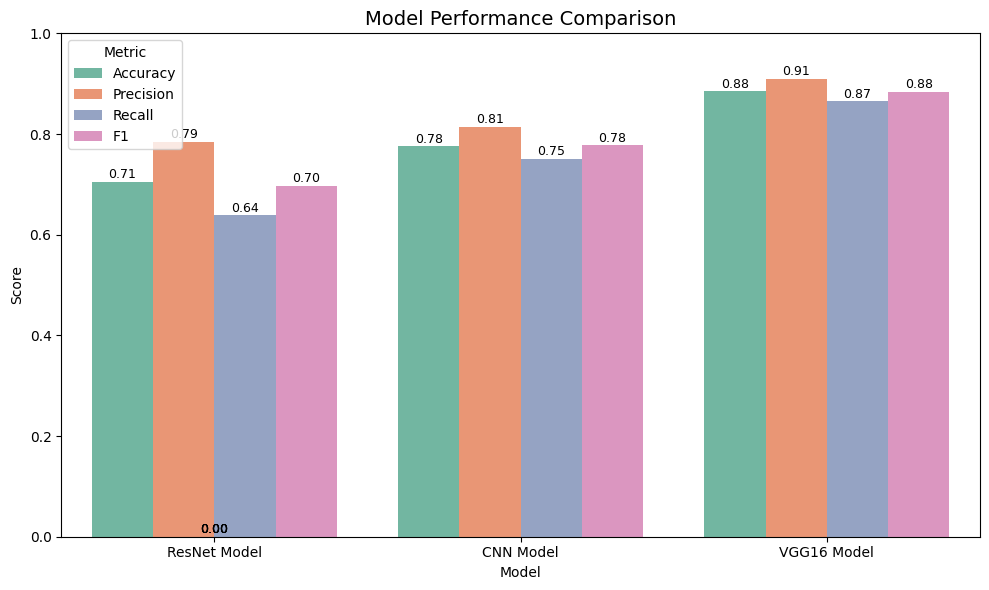

In [78]:
df_melted = final_metrics.melt(id_vars="Model Name", var_name="Metric", value_name="Score")

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x="Model Name", y="Score", hue="Metric", data=df_melted, palette="Set2")

# Add labels and title
plt.title("Model Performance Comparison", fontsize=14)
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)  # Since scores are between 0 and 1
plt.legend(title="Metric")

# Show values on bars
for p in plt.gca().patches:
    plt.gca().annotate(f"{p.get_height():.2f}",
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center',
                       fontsize=9, color='black', xytext=(0, 5),
                       textcoords='offset points')

plt.tight_layout()
plt.show()

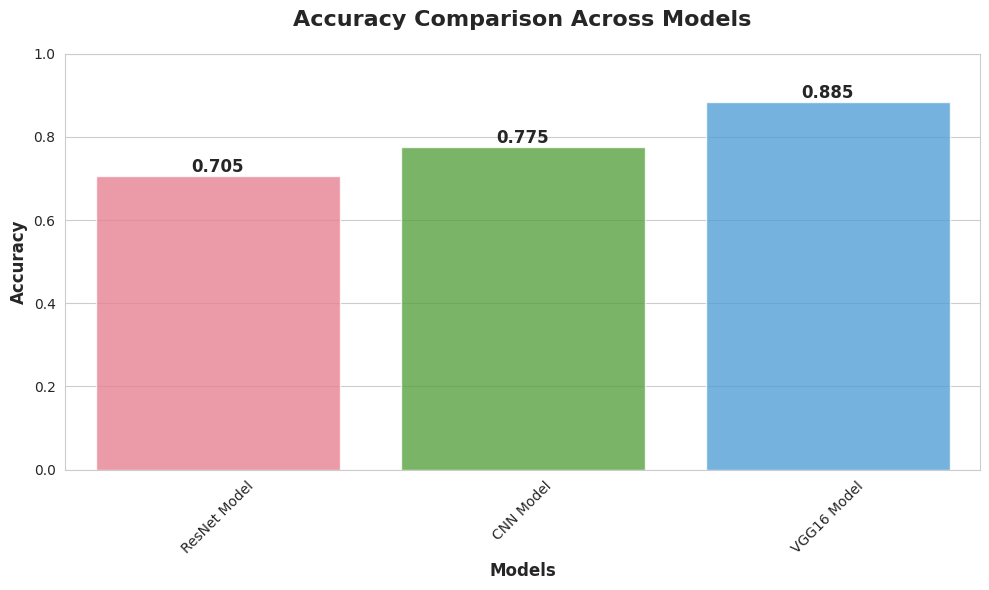

In [79]:
# Set style and color palette
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
colors = sns.color_palette("husl", 3)  # Different colors for each model

# 1. Accuracy Plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Model Name', y='Accuracy', data=final_metrics, hue="Model Name", palette=colors, alpha=0.8)
plt.title('Accuracy Comparison Across Models', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Models', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.ylim(0, 1.0)

# Add value annotations on bars
for i, p in enumerate(ax.patches):
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

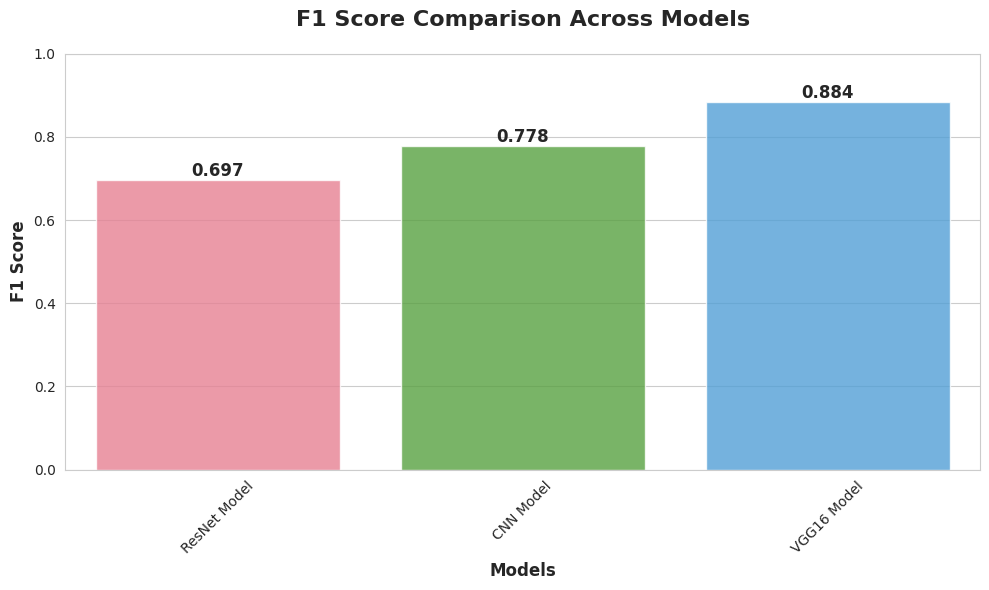

In [80]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Model Name', y='F1', data=final_metrics, hue="Model Name", palette=colors, alpha=0.8)
plt.title('F1 Score Comparison Across Models', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Models', fontsize=12, fontweight='bold')
plt.ylabel('F1 Score', fontsize=12, fontweight='bold')
plt.ylim(0, 1.0)

for i, p in enumerate(ax.patches):
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

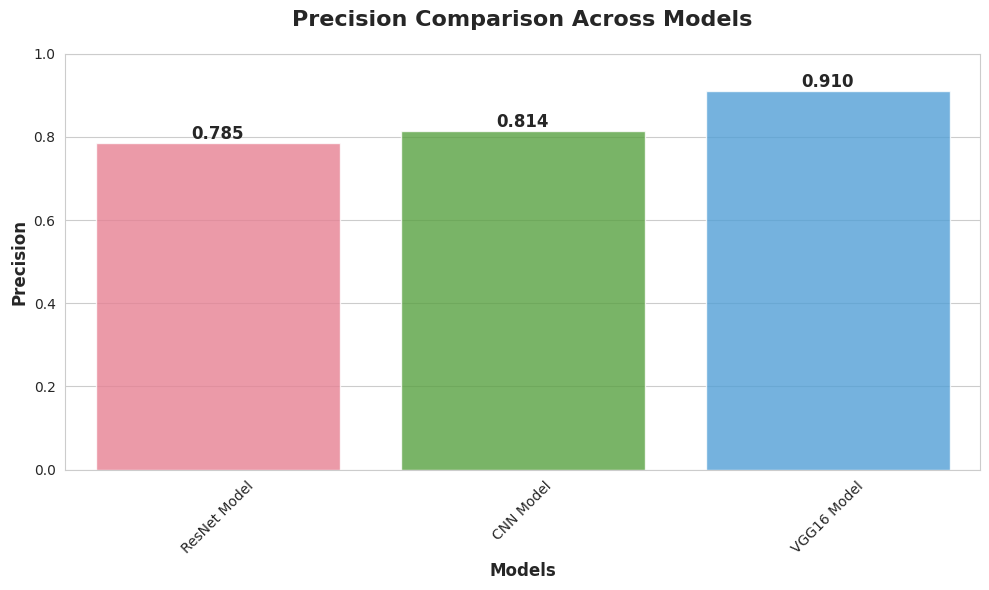

In [81]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Model Name', y='Precision', data=final_metrics, hue="Model Name", palette=colors, alpha=0.8)
plt.title('Precision Comparison Across Models', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Models', fontsize=12, fontweight='bold')
plt.ylabel('Precision', fontsize=12, fontweight='bold')
plt.ylim(0, 1.0)

for i, p in enumerate(ax.patches):
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

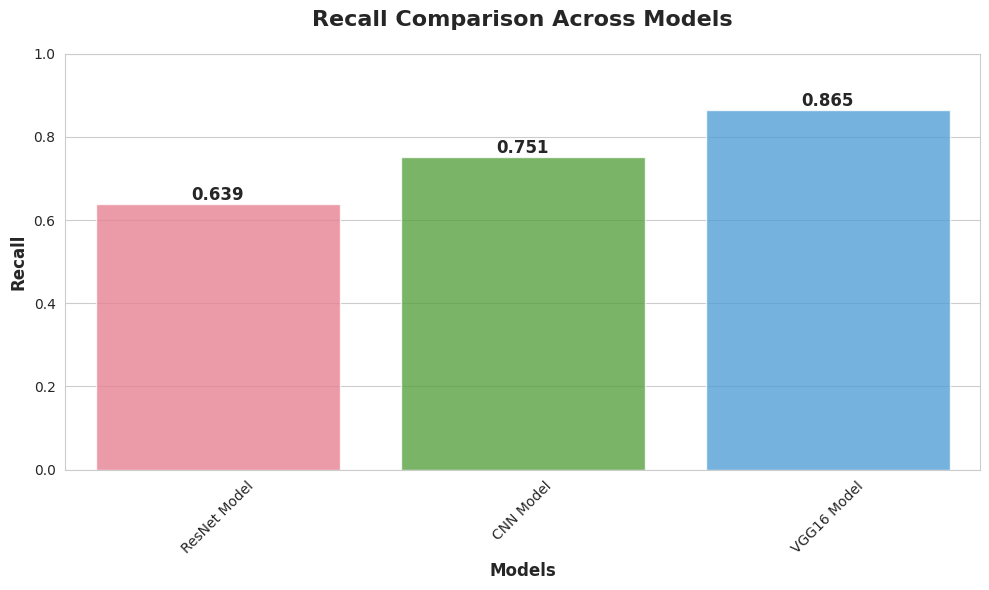

In [82]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Model Name', y='Recall', data=final_metrics, hue="Model Name", palette=colors, alpha=0.8)
plt.title('Recall Comparison Across Models', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Models', fontsize=12, fontweight='bold')
plt.ylabel('Recall', fontsize=12, fontweight='bold')
plt.ylim(0, 1.0)

for i, p in enumerate(ax.patches):
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

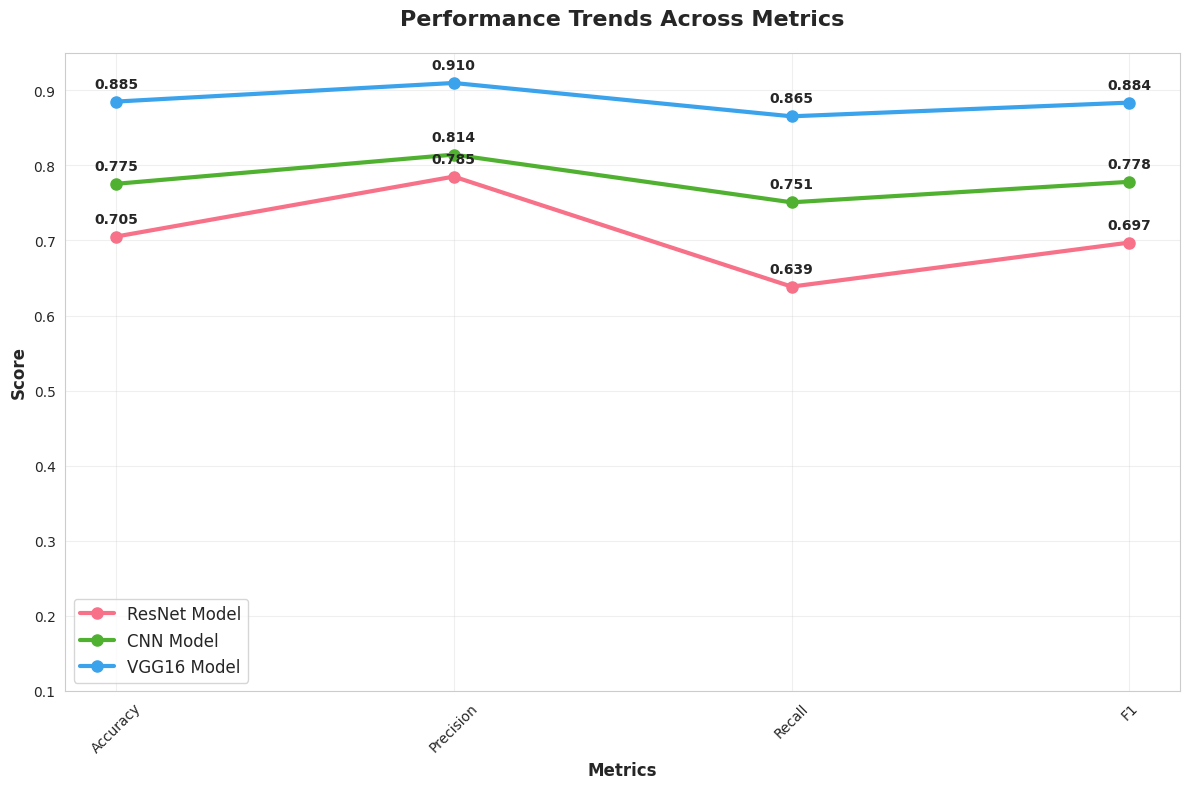

In [83]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
df_melted = final_metrics.melt(id_vars=['Model Name'], value_vars=metrics,
                   var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 8))
for i, model in enumerate(final_metrics['Model Name']):
    model_data = final_metrics[final_metrics['Model Name'] == model]
    plt.plot(metrics, model_data[metrics].values[0],
             marker='o', linewidth=3, markersize=8,
             label=model, color=colors[i])

plt.title('Performance Trends Across Metrics', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Metrics', fontsize=12, fontweight='bold')
plt.ylabel('Score', fontsize=12, fontweight='bold')
plt.ylim(0.1, 0.95)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

# Add value annotations
for i, model in enumerate(final_metrics['Model Name']):
    model_data = final_metrics[final_metrics['Model Name'] == model]
    for j, metric in enumerate(metrics):
        plt.annotate(f'{model_data[metric].values[0]:.3f}',
                    (j, model_data[metric].values[0]),
                    textcoords="offset points",
                    xytext=(0,10),
                    ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## **Test Predictions**

In [85]:
# Get class labels from test_generator
class_labels = list(test_generator.class_indices.keys())

def get_random_test_images(num_images=5):
    test_image_paths = []
    for class_folder in os.listdir(test_dir):
        class_path = os.path.join(test_dir, class_folder)
        if os.path.isdir(class_path):
            for img_name in os.listdir(class_path):
                test_image_paths.append(os.path.join(class_path, img_name))

    # Randomly select num_images image paths
    random.shuffle(test_image_paths)
    return test_image_paths[:num_images]


def preprocess_image(image_path, target_size=(224, 224)):
    img = Image.open(image_path)
    img = img.resize(target_size)
    img_array = np.array(img)
    img_array = np.expand_dims(img_array, axis=0) # Add batch dimension
    img_array = img_array / 255.0 # Rescale
    return img_array

# Get 5 random test images
random_image_paths = get_random_test_images(num_images=5)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step


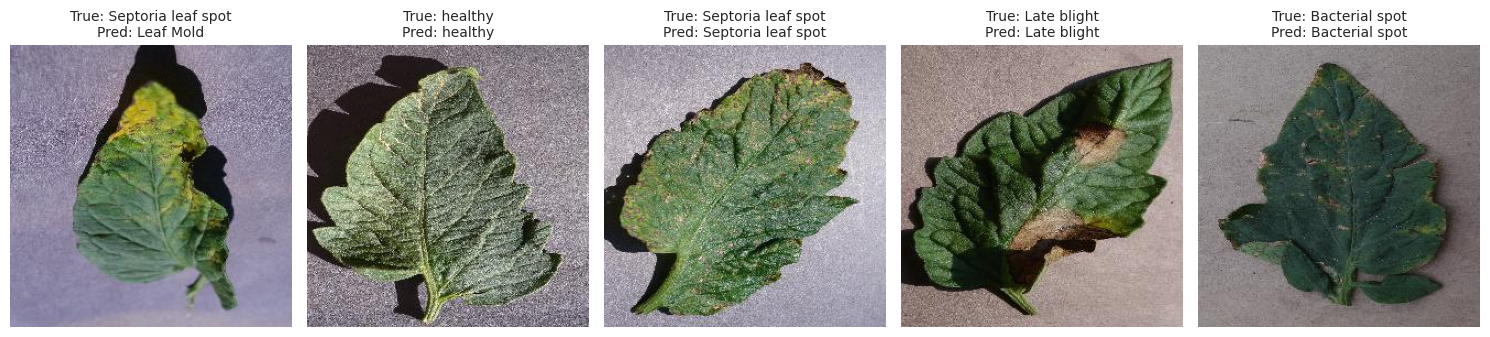

In [86]:
plt.figure(figsize=(15, 8))
for i, img_path in enumerate(random_image_paths):
    # Preprocess the image
    processed_img = preprocess_image(img_path)

    # Make prediction using VGG16 model
    predictions = vgg_model.predict(processed_img)
    predicted_class_index = np.argmax(predictions, axis=1)[0]
    predicted_label = class_labels[predicted_class_index]

    # Get true label from the path
    true_label = os.path.basename(os.path.dirname(img_path))

    # Display the image and prediction
    plt.subplot(1, 5, i + 1)
    plt.imshow(Image.open(img_path))
    plt.title(f"True: {true_label}\nPred: {predicted_label}", fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

## **Grad-CAM**

In [88]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):

    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


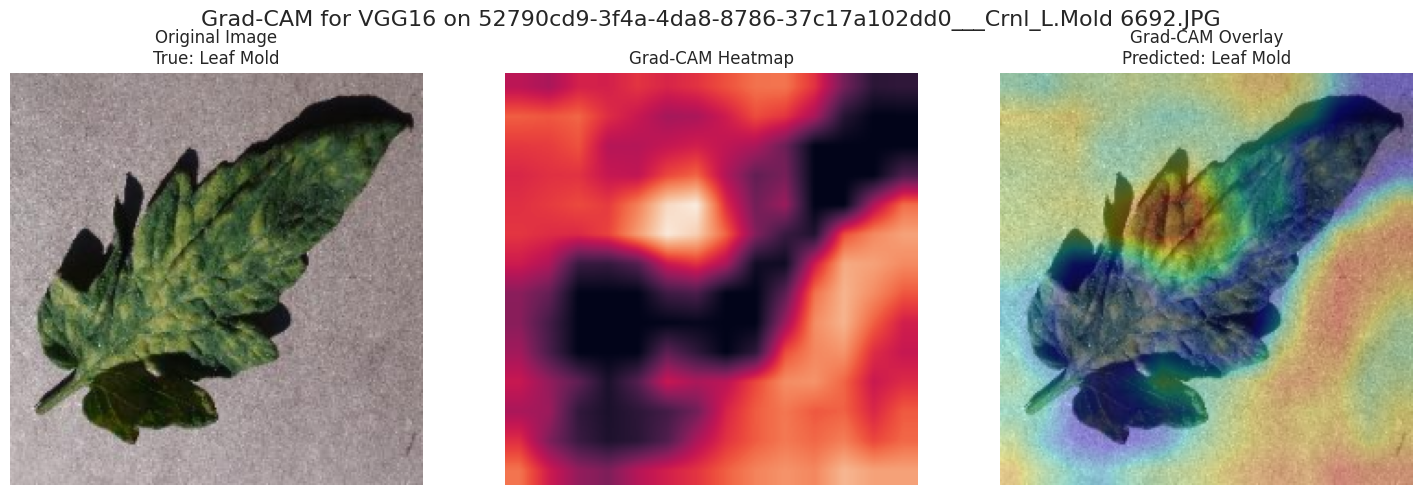

In [90]:
# Select a random image
import cv2

random_image_paths = get_random_test_images(num_images=1)
if not random_image_paths:
    print("No images found in the test directory.")
else:
    img_path = random_image_paths[0]
    preprocessed_image = preprocess_image(img_path)

    # Get predictions
    predictions = vgg_model.predict(preprocessed_image)
    predicted_class_index = np.argmax(predictions[0])
    predicted_label = class_labels[predicted_class_index]
    true_label = os.path.basename(os.path.dirname(img_path))

    # Get the name of the last convolutional layer for VGG16
    last_conv_layer_name = 'block5_conv3'

    # Generate Grad-CAM heatmap
    heatmap = make_gradcam_heatmap(preprocessed_image, vgg_model, last_conv_layer_name)

    # Load the original image
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize heatmap to the original image size
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

    # Apply colormap to heatmap
    heatmap = np.uint8(255 * heatmap)
    jet = plt.colormaps['jet'] # Use a colormap to colorize the heatmap
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    # Create an image with RGB colorized heatmap
    jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = np.array(jet_heatmap)

    # Superimpose the heatmap on original image
    superimposed_img = jet_heatmap * 0.4 + img # 0.4 is an overlay intensity factor
    superimposed_img = tf.keras.preprocessing.image.array_to_img(superimposed_img)

    # Display the results
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img)
    axes[0].set_title(f"Original Image\nTrue: {true_label}")
    axes[0].axis('off')

    axes[1].imshow(heatmap)
    axes[1].set_title("Grad-CAM Heatmap")
    axes[1].axis('off')

    axes[2].imshow(superimposed_img)
    axes[2].set_title(f"Grad-CAM Overlay\nPredicted: {predicted_label}")
    axes[2].axis('off')

    plt.suptitle(f"Grad-CAM for VGG16 on {os.path.basename(img_path)}", fontsize=16)
    plt.tight_layout()
    plt.show()